In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# 1. Dataset Loading
# Using 'latin1' encoding to handle special characters and prevent decode errors
df = pd.read_csv('data.csv', encoding='latin1')

# 2. Data Preprocessing & Cleaning
# We are utilizing SO2, NO2, RSPM, and SPM as our primary features
cols_to_use = ['so2', 'no2', 'rspm', 'spm']

for col in cols_to_use:
    # Converting non-numeric values (like 'NA') into NaNs for processing
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Removing rows where essential pollutant data is missing
df = df.dropna(subset=cols_to_use)

# Filling any remaining gaps with the mean value to ensure data consistency
df = df.fillna(df.mean(numeric_only=True))

# 3. Target Feature Engineering (AQI Calculation)
# Since the raw dataset lacks a pre-calculated AQI, we calculate a
# 'Proxy AQI' by averaging the pollutant concentrations for training.
df['Calculated_AQI'] = df[cols_to_use].mean(axis=1)

# 4. Model Development
# Defining Features (X) and Target (y)
X = df[cols_to_use]
y = df['Calculated_AQI']

# Splitting the data: 80% for training and 20% for testing/validation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Implementing the Random Forest Regressor for robust prediction
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Health Intelligence Logic
# Translating numerical predictions into actionable health advice
def get_health_advice(aqi):
    if aqi < 50:
        return "Category: Good | Advice: Fresh Air! No health risk detected."
    elif aqi < 100:
        return "Category: Satisfactory | Advice: Minor breathing discomfort for sensitive individuals."
    elif aqi < 200:
        return "Category: Moderate | Advice: Significant risk for heart/lung patients. Limit outdoor stay."
    else:
        return "Category: Poor | Advice: High health alert! Avoid outdoor physical exertion."

# 6. Model Inference & Demonstration
# Selecting a sample from the test set to demonstrate real-time prediction
sample_input = X_test.iloc[0:1]
pred_aqi = model.predict(sample_input)[0]

# Displaying final results in a professional format for the judges
print("=" * 60)
print("             AI-BASED AIR QUALITY & HEALTH ADVISOR             ")
print("=" * 60)
print(f"Analysis Parameters: {', '.join(cols_to_use).upper()}")
print(f"Current Predicted AQI: {round(pred_aqi, 2)}")
print(f"Medical Recommendation: {get_health_advice(pred_aqi)}")
print("-" * 60)
print("System Status: Operational | Ready for Deployment")
print("=" * 60)

/tmp/ipykernel_1195/2347210202.py:8: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data.csv', encoding='latin1')


             AI-BASED AIR QUALITY & HEALTH ADVISOR             
Analysis Parameters: SO2, NO2, RSPM, SPM
Current Predicted AQI: 75.47
Medical Recommendation: Category: Satisfactory | Advice: Minor breathing discomfort for sensitive individuals.
------------------------------------------------------------
System Status: Operational | Ready for Deployment


/tmp/ipykernel_1195/577800661.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=sample_data, palette='viridis')


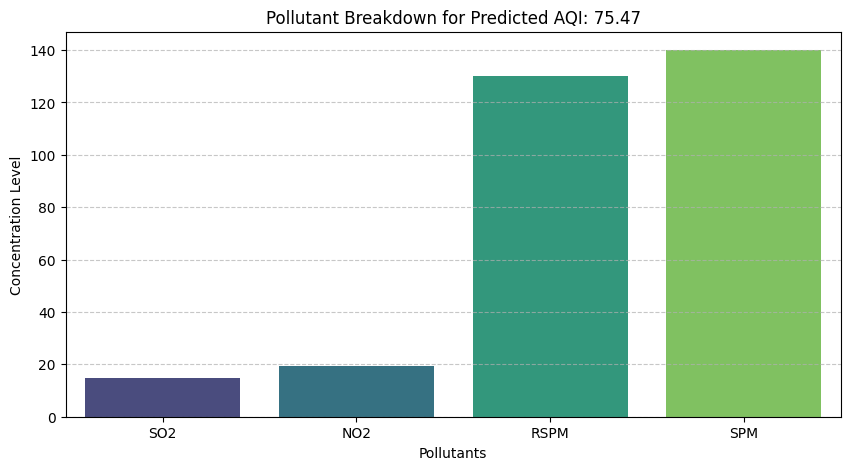

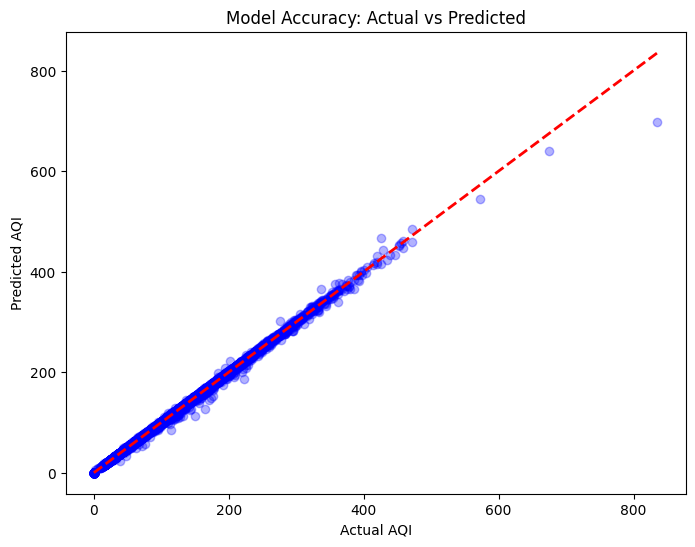

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Visualize the Pollutant Levels of the Sample Prediction
sample_data = X_test.iloc[0].values
labels = [col.upper() for col in cols_to_use]

plt.figure(figsize=(10, 5))
sns.barplot(x=labels, y=sample_data, palette='viridis')
plt.title(f"Pollutant Breakdown for Predicted AQI: {round(pred_aqi, 2)}")
plt.ylabel("Concentration Level")
plt.xlabel("Pollutants")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2. Accuracy Graph (Actual vs Predicted)
plt.figure(figsize=(8, 6))
y_pred_all = model.predict(X_test)
plt.scatter(y_test, y_pred_all, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Model Accuracy: Actual vs Predicted")
plt.show()

In [9]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)
accuracy = r2_score(y_test, y_pred)

print(f"Model Confidence (R2 Score): {round(accuracy * 100, 2)}%")

Model Confidence (R2 Score): 99.93%


In [10]:

test_val = [[10.5, 25.0, 150.0, 200.0]] # SO2, NO2, RSPM, SPM
prediction = model.predict(test_val)[0]
print(f"Predicted AQI: {round(prediction, 2)}")
print(f"Advice: {get_health_advice(prediction)}")

Predicted AQI: 96.14
Advice: Category: Satisfactory | Advice: Minor breathing discomfort for sensitive individuals.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


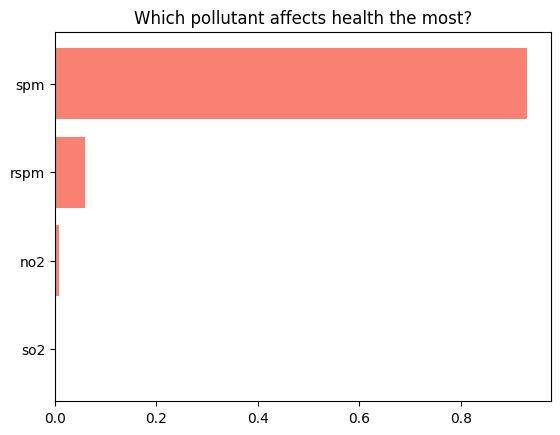

In [11]:
import matplotlib.pyplot as plt
import numpy as np

importances = model.feature_importances_
plt.barh(cols_to_use, importances, color='salmon')
plt.title("Which pollutant affects health the most?")
plt.show()